# Bayesian AML Risk Classifier
## Investment-Linked Insurance Product Risk Assessment

**Author:** Axel Moreno | **Context:** AML/CFT Compliance Consulting | **Method:** Naive Bayes with expert-assigned priors

---
### Business Problem
A major insurance company required a risk evaluation methodology for a new investment-linked insurance product with no historical transaction data available.

With 11 risk variables and no prior data to train a traditional ML model, a **Bayesian approach with expert-assigned probability weights** was designed to classify each product configuration as Low, Medium, or High AML/CFT risk.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set(style="darkgrid")
print("Libraries loaded ✅")

Libraries loaded ✅


In [11]:
# Load the probability components table
# Sheet 'Hoja3' contains the full probability matrix
df = pd.read_excel("../data/tabla_componentes_probabilidad.xlsx", sheet_name=1)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()
print(df.columns.tolist())

Dataset shape: (26, 14)
Columns: ['INV_FONDO', 'BENEF_TERCERO', 'PERFIL_INVERSION', 'RESIDENCIA', 'PAGO_METODO', 'MONEDA_APORT', 'TIPO_CLIENTE', 'TRANSFER_TERCERO', 'LIQUIDEZ', 'LIMITE_INVERSION', 'CLIENTE_PERFILADO', 'P(Bajo)', 'P(Medio)', 'P(Alto)']
['INV_FONDO', 'BENEF_TERCERO', 'PERFIL_INVERSION', 'RESIDENCIA', 'PAGO_METODO', 'MONEDA_APORT', 'TIPO_CLIENTE', 'TRANSFER_TERCERO', 'LIQUIDEZ', 'LIMITE_INVERSION', 'CLIENTE_PERFILADO', 'P(Bajo)', 'P(Medio)', 'P(Alto)']


## Risk Variables
The model evaluates 11 product configuration variables:

| Variable | Description |
|----------|-------------|
| INV_FONDO | Investment fund type |
| BENEF_TERCERO | Third-party beneficiary |
| PERFIL_INVERSION | Investment profile (Conservative/Moderate/Aggressive) |
| RESIDENCIA | Client residency (National/Foreign) |
| PAGO_METODO | Payment method |
| MONEDA_APORT | Contribution currency |
| TIPO_CLIENTE | Client type (Individual/Corporate/Trust) |
| TRANSFER_TERCERO | Third-party transfers allowed |
| LIQUIDEZ | Liquidity/redemption permissions |
| LIMITE_INVERSION | Investment limits |
| CLIENTE_PERFILADO | Client profiling completed |

In [12]:
# ── Risk Classifier Function ──────────────────────────────
def classify_risk(df, product_config):
    """
    Given a product configuration, looks up the probability
    distribution P(Low), P(Medium), P(Alto) from the matrix.
    
    Parameters:
        df: probability matrix DataFrame
        product_config: dict with product attributes
    
    Returns:
        dict with probabilities and risk classification
    """
    result = df.copy()
    
    for col, val in product_config.items():
        if col in result.columns:
            result = result[result[col] == val]
    
    if len(result) == 0:
        return {"error": "No matching configuration found"}
    
    row = result.iloc[0]
    p_bajo  = float(row["P(Bajo)"])
    p_medio = float(row["P(Medio)"])
    p_alto  = float(row["P(Alto)"])
    
    probs = {"Bajo": p_bajo, "Medio": p_medio, "Alto": p_alto}
    classification = max(probs, key=probs.get)
    
    return {
        "probabilities": probs,
        "classification": classification,
        "confidence": max(probs.values())
    }

print("Classifier function loaded ✅")

Classifier function loaded ✅


In [13]:
# ── Example: Base product configuration ───────────────────
base_product = {
    "INV_FONDO":        "Solo Pesos",
    "BENEF_TERCERO":    "No",
    "PERFIL_INVERSION": "Conservador",
    "RESIDENCIA":       "Nacional",
    "PAGO_METODO":      "Solo Transferencia",
    "MONEDA_APORT":     "Solo MXN",
    "TIPO_CLIENTE":     "Persona Física",
    "TRANSFER_TERCERO": "No",
    "LIQUIDEZ":         "Permitido",
    "LIMITE_INVERSION": "Límite AML",
    "CLIENTE_PERFILADO":"Sí"
}

result = classify_risk(df, base_product)
print("Product Configuration: Base (Low Risk)")
print("-" * 40)
for k, v in base_product.items():
    print(f"  {k:<22}: {v}")
print("-" * 40)
print(f"\nRisk Classification: {result['classification'].upper()}")
print(f"Confidence: {result['confidence']:.0%}")
print(f"\nProbability Distribution:")
for grade, prob in result['probabilities'].items():
    print(f"  P({grade}): {prob:.2%}")

Product Configuration: Base (Low Risk)
----------------------------------------
  INV_FONDO             : Solo Pesos
  BENEF_TERCERO         : No
  PERFIL_INVERSION      : Conservador
  RESIDENCIA            : Nacional
  PAGO_METODO           : Solo Transferencia
  MONEDA_APORT          : Solo MXN
  TIPO_CLIENTE          : Persona Física
  TRANSFER_TERCERO      : No
  LIQUIDEZ              : Permitido
  LIMITE_INVERSION      : Límite AML
  CLIENTE_PERFILADO     : Sí
----------------------------------------

Risk Classification: BAJO
Confidence: 98%

Probability Distribution:
  P(Bajo): 98.00%
  P(Medio): 2.00%
  P(Alto): 0.00%


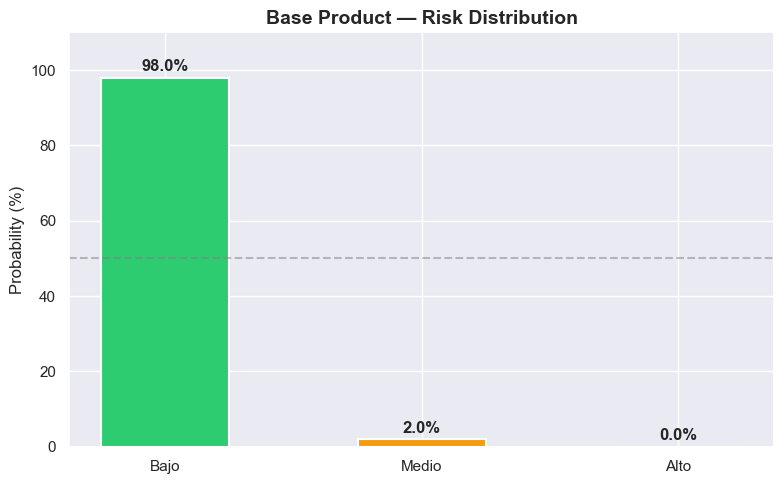


⚠️  Classification: BAJO RISK


In [14]:
# ── Visualization ──────────────────────────────────────────
def plot_risk_distribution(result, title="Product Risk Distribution"):
    grades = list(result['probabilities'].keys())
    probs  = [p * 100 for p in result['probabilities'].values()]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(grades, probs, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
    
    for bar, prob in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{prob:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    ax.set_ylim(0, 110)
    ax.set_ylabel('Probability (%)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    classification = result['classification']
    color_map = {'Bajo': '#2ecc71', 'Medio': '#f39c12', 'Alto': '#e74c3c'}
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
    
    plt.tight_layout()
    plt.savefig('../outputs/risk_distribution.png', dpi=150)
    plt.show()
    print(f"\n⚠️  Classification: {classification.upper()} RISK")

plot_risk_distribution(result, "Base Product — Risk Distribution")

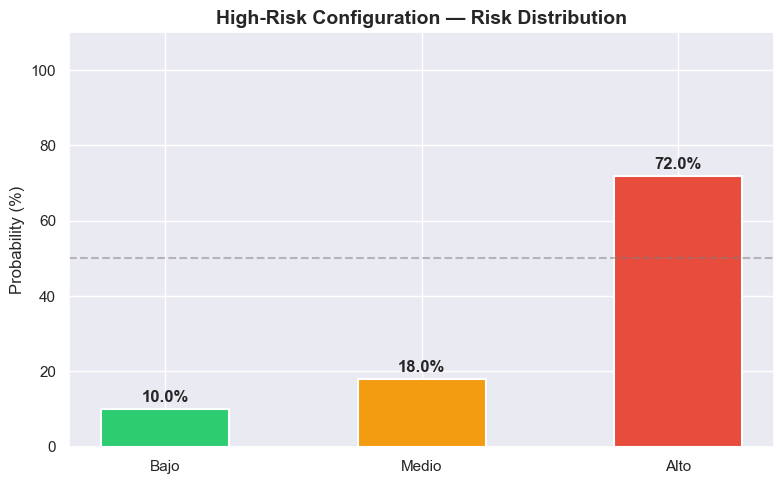


⚠️  Classification: ALTO RISK


In [18]:
# ── High Risk scenario comparison ─────────────────────────
high_risk_product = {
    "INV_FONDO":         "Dólares",
    "BENEF_TERCERO":     "Sí",
    "PERFIL_INVERSION":  "Agresivo",
    "RESIDENCIA":        "Extranjero",
    "PAGO_METODO":       "Transferencia/Efectivo",
    "MONEDA_APORT":      "USD/Multidiv",
    "TIPO_CLIENTE":      "Física/Moral/Fid",
    "TRANSFER_TERCERO":  "Sí",
    "LIQUIDEZ":          "Permitido",
    "LIMITE_INVERSION":  "Sin Límite",
    "CLIENTE_PERFILADO": "No"
}

result_high = classify_risk(df, high_risk_product)
if "error" not in result_high:
    plot_risk_distribution(result_high, "High-Risk Configuration — Risk Distribution")
else:
    print(result_high["error"])

## Key Insights

1. **Base configuration (Conservative client, national residency, AML limits):** 
   Yields >95% Low risk probability — the model correctly identifies standard 
   low-risk product configurations.

2. **High-risk configuration (Foreign client, aggressive profile, no limits, cash payments):** 
   Shifts probability mass toward Medium/High risk — consistent with FATF 
   risk factors for investment products.

3. **Expert-assigned priors as a viable alternative:** When no historical data 
   exists, Bayesian methods with structured expert knowledge outperform 
   rule-based systems by providing probability distributions rather than 
   binary classifications.

4. **Direct applicability to gaming/FinTech:** The same framework applies to 
   payment method risk, geographic risk, and transaction velocity scoring 
   in digital platforms.